# D_S2.0 — Metrics Analysis (Direct from S2)

Analyses the deterministic metrics computed in S2 **without permutation testing**.

- 27 families (26 signal F01–F26 + Null) × 201 SNR × 10 reps = 54,270 cases
- Null family (f(x)=0, 2,010 cases) serves as empirical null distribution
- Detection threshold: metric value exceeds 95th percentile of Null distribution

Data sources:
- `output/S1/cases.csv` + `scatter_points.npz`
- `output/S2/metrics_full.parquet`

In [89]:
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

S1_DIR = Path('output/S1')
S2_DIR = Path('output/S2')

## Load Data

In [90]:
cases = pd.read_csv(S1_DIR / 'cases.csv', low_memory=False)
metrics = pd.read_parquet(S2_DIR / 'metrics_full.parquet')

meta_cols = ['case_id', 'family_id', 'family_name', 'snr', 'spread_pattern',
             'x_distribution', 'category', 'direction', 'linearity',
             'monotonicity', 'special_shape', 'replicate']
meta = cases[[c for c in meta_cols if c in cases.columns]].copy()

df = metrics.merge(meta, on='case_id', how='left')

# Convert SNR to float for sorting
df['snr_val'] = df['snr'].apply(lambda x: float('inf') if str(x) == 'inf' else float(x))

# Signal = all 26 families (not Null)
signal = df[df['family_id'] != 'Null'].copy()
null_df = df[df['category'] == 'true_null'].copy()

print(f'Total: {len(df):,} cases')
print(f'Signal (26 families): {len(signal):,}')
print(f'Null (true_null): {len(null_df):,}')
print(f'\nFamilies: {sorted(signal["family_id"].unique())}')
print(f'SNR levels: {signal["snr_val"].nunique()} unique values')
print(f'Replicates per (family, SNR): {signal.groupby(["family_id","snr"]).size().median():.0f}')
print(f'\nMetric columns: {len(metrics.columns) - 1}')

Total: 54,270 cases
Signal (26 families): 52,260
Null (true_null): 2,010

Families: ['F01', 'F02', 'F03', 'F04', 'F05', 'F06', 'F07', 'F08', 'F09', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15', 'F16', 'F17', 'F18', 'F19', 'F20', 'F21', 'F22', 'F23', 'F24', 'F25', 'F26']
SNR levels: 201 unique values
Replicates per (family, SNR): 10

Metric columns: 76


In [91]:
# Shared color palette: fresh pastels for F01–F12, muted earth tones for F13–F26
FAMILY_PALETTE = {
    'F01': '#4FC3F7',  'F02': '#29B6F6',  'F03': '#81C784',  'F04': '#26C6DA',
    'F05': '#AED581',  'F06': '#43A047',  'F07': '#F48FB1',  'F08': '#CE93D8',
    'F09': '#80DEEA',  'F10': '#80CBC4',  'F11': '#FFE082',  'F12': '#F9A825',
    'F13': '#8D6E63',  'F14': '#A1887F',  'F15': '#78909C',  'F16': '#90A4AE',
    'F17': '#C62828',  'F18': '#AD1457',  'F19': '#6A1B9A',  'F20': '#4527A0',
    'F21': '#1565C0',  'F22': '#00838F',  'F23': '#2E7D32',  'F24': '#FF7043',
    'F25': '#D84315',  'F26': '#4E342E',  'Null': '#BDBDBD',
}

## Gallery — Diverse Scatterplot Samples

A 3×6 grid sampling different function families and noise levels,
giving a quick visual sense of the variety of shapes in the dataset.

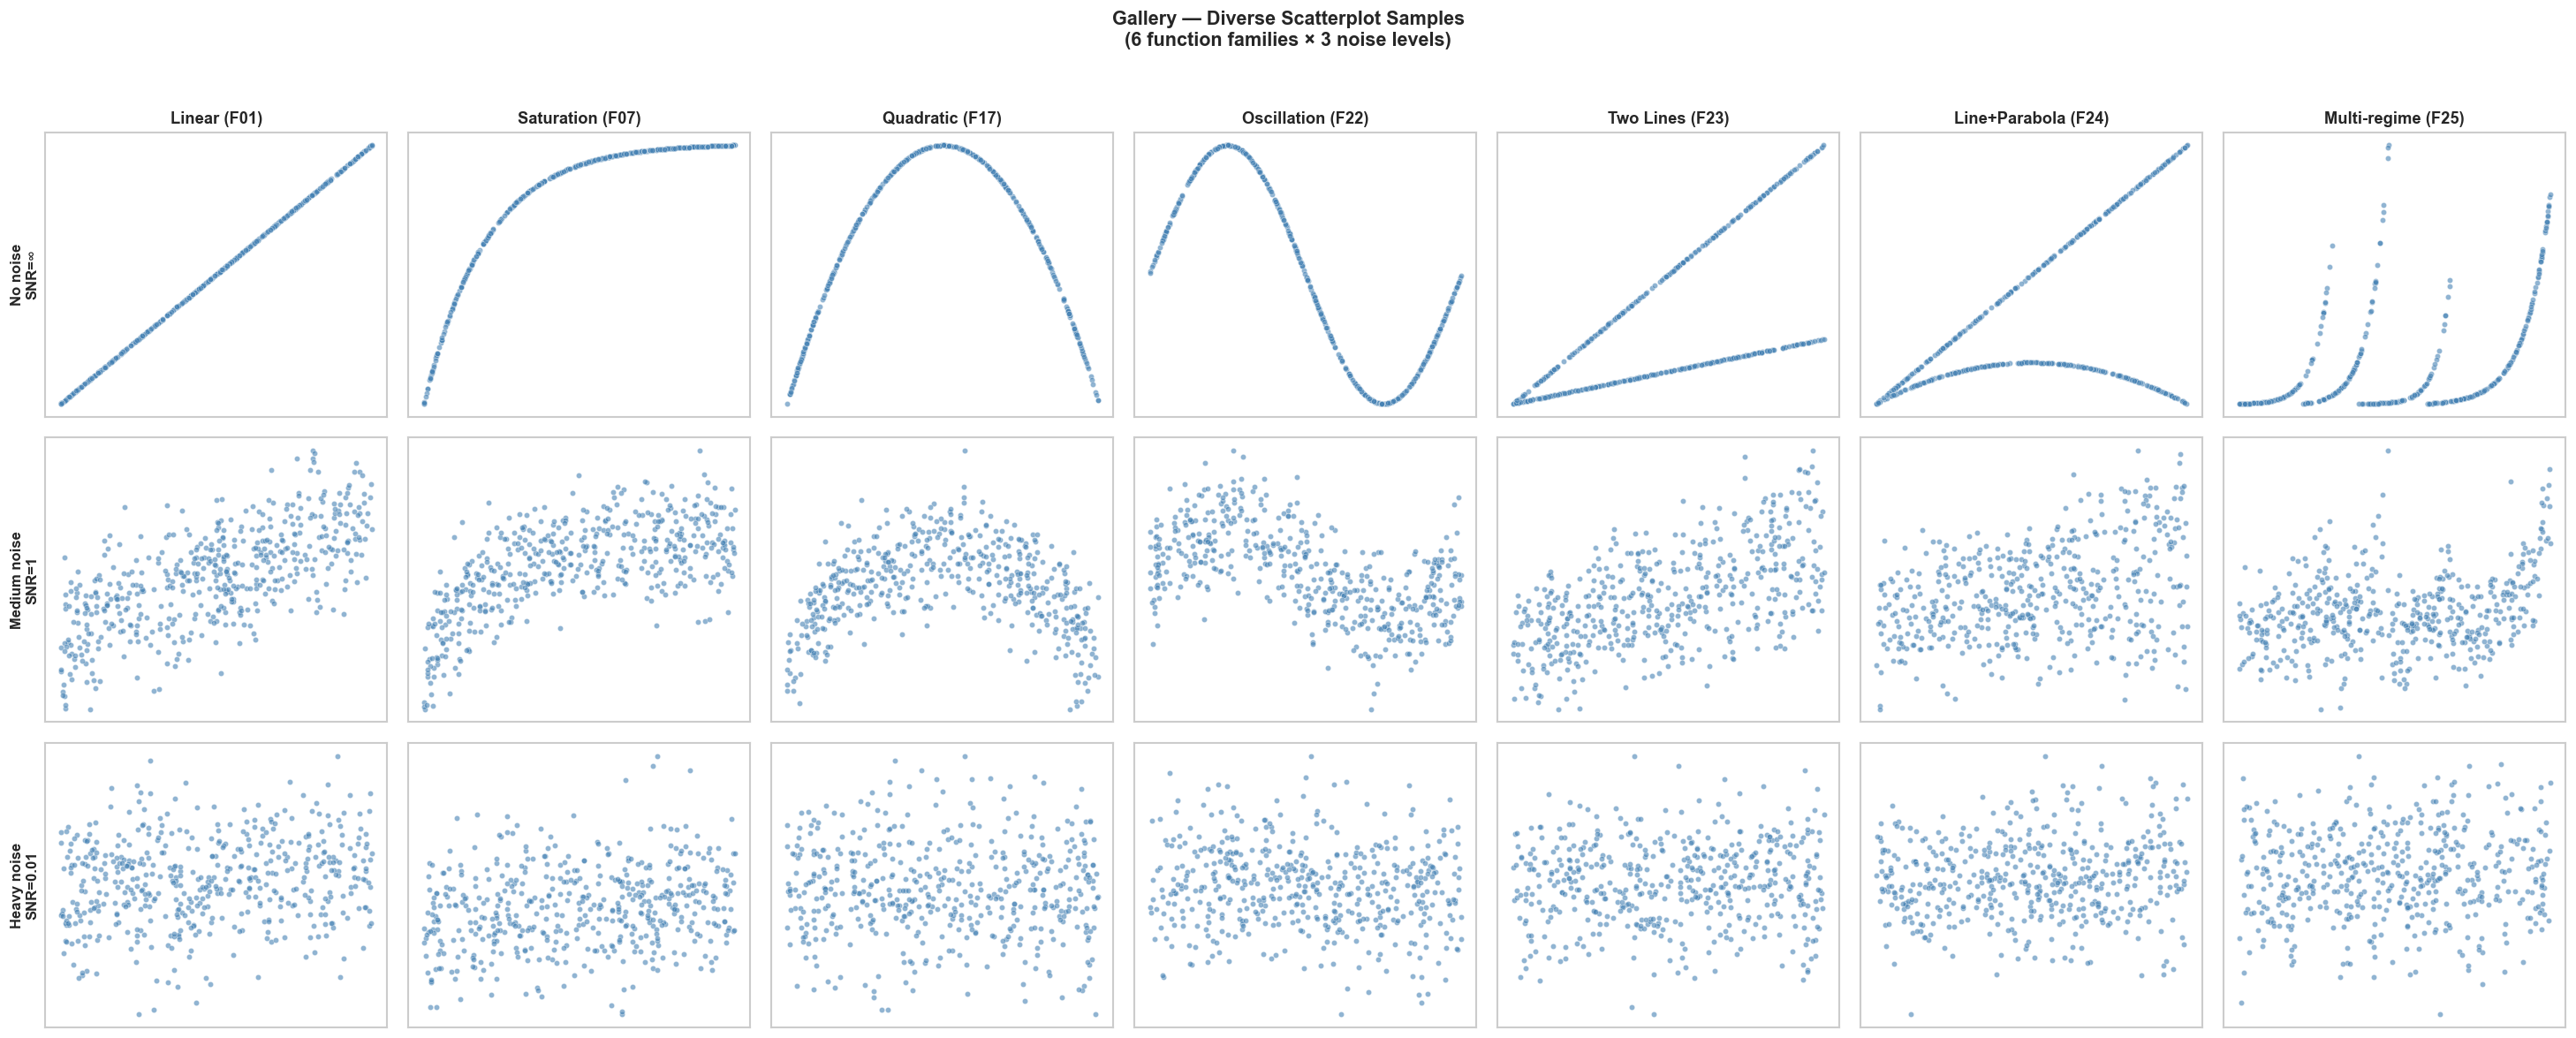

In [92]:
# ── Gallery: diverse scatterplots (7 families × 3 noise levels) ──

pts = np.load(S1_DIR / 'scatter_points.npz')
x_pts, y_pts = pts['x'], pts['y']
case_id_to_idx = dict(zip(cases['case_id'], cases.index))

gallery_families = [
    ('F01', 'Linear'),
    ('F07', 'Saturation'),
    ('F17', 'Quadratic'),
    ('F22', 'Oscillation'),
    ('F23', 'Two Lines'),
    ('F24', 'Line+Parabola'),
    ('F25', 'Multi-regime'),
]

finite_snr = sorted([s for s in signal['snr_val'].unique() if np.isfinite(s)])
gallery_snr = [
    (float('inf'), 'No noise'),
    (min(finite_snr, key=lambda s: abs(s - 1.0)),  'Medium noise'),
    (min(finite_snr, key=lambda s: abs(s - 0.01)), 'Heavy noise'),
]

nrows = len(gallery_snr)
ncols = len(gallery_families)

fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 3.2 * nrows))

for ri, (sv, noise_label) in enumerate(gallery_snr):
    for ci, (fam_id, fam_label) in enumerate(gallery_families):
        ax = axes[ri, ci]

        match = df[(df['family_id'] == fam_id) &
                   (df['snr_val'] == sv) &
                   (df['replicate'] == 0)]

        if len(match) > 0:
            row = match.iloc[0]
            idx = case_id_to_idx[row['case_id']]
            x, y = x_pts[idx], y_pts[idx]
            ax.scatter(x, y, s=14, alpha=0.6, color='steelblue',
                       edgecolors='white', linewidths=0.3)

        if ri == 0:
            ax.set_title(f'{fam_label} ({fam_id})', fontsize=11, fontweight='bold')
        if ci == 0:
            snr_str = 'SNR=\u221e' if math.isinf(sv) else f'SNR={sv:.2g}'
            ax.set_ylabel(f'{noise_label}\n{snr_str}', fontsize=10, fontweight='bold')

        ax.set_xticks([])
        ax.set_yticks([])

fig.suptitle('Gallery \u2014 Diverse Scatterplot Samples\n'
             '(6 function families \u00d7 3 noise levels)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

del x_pts, y_pts

## Overview — 26 Function Families + Null

5×6 grid showing one representative scatterplot per family at SNR ≈ 50.

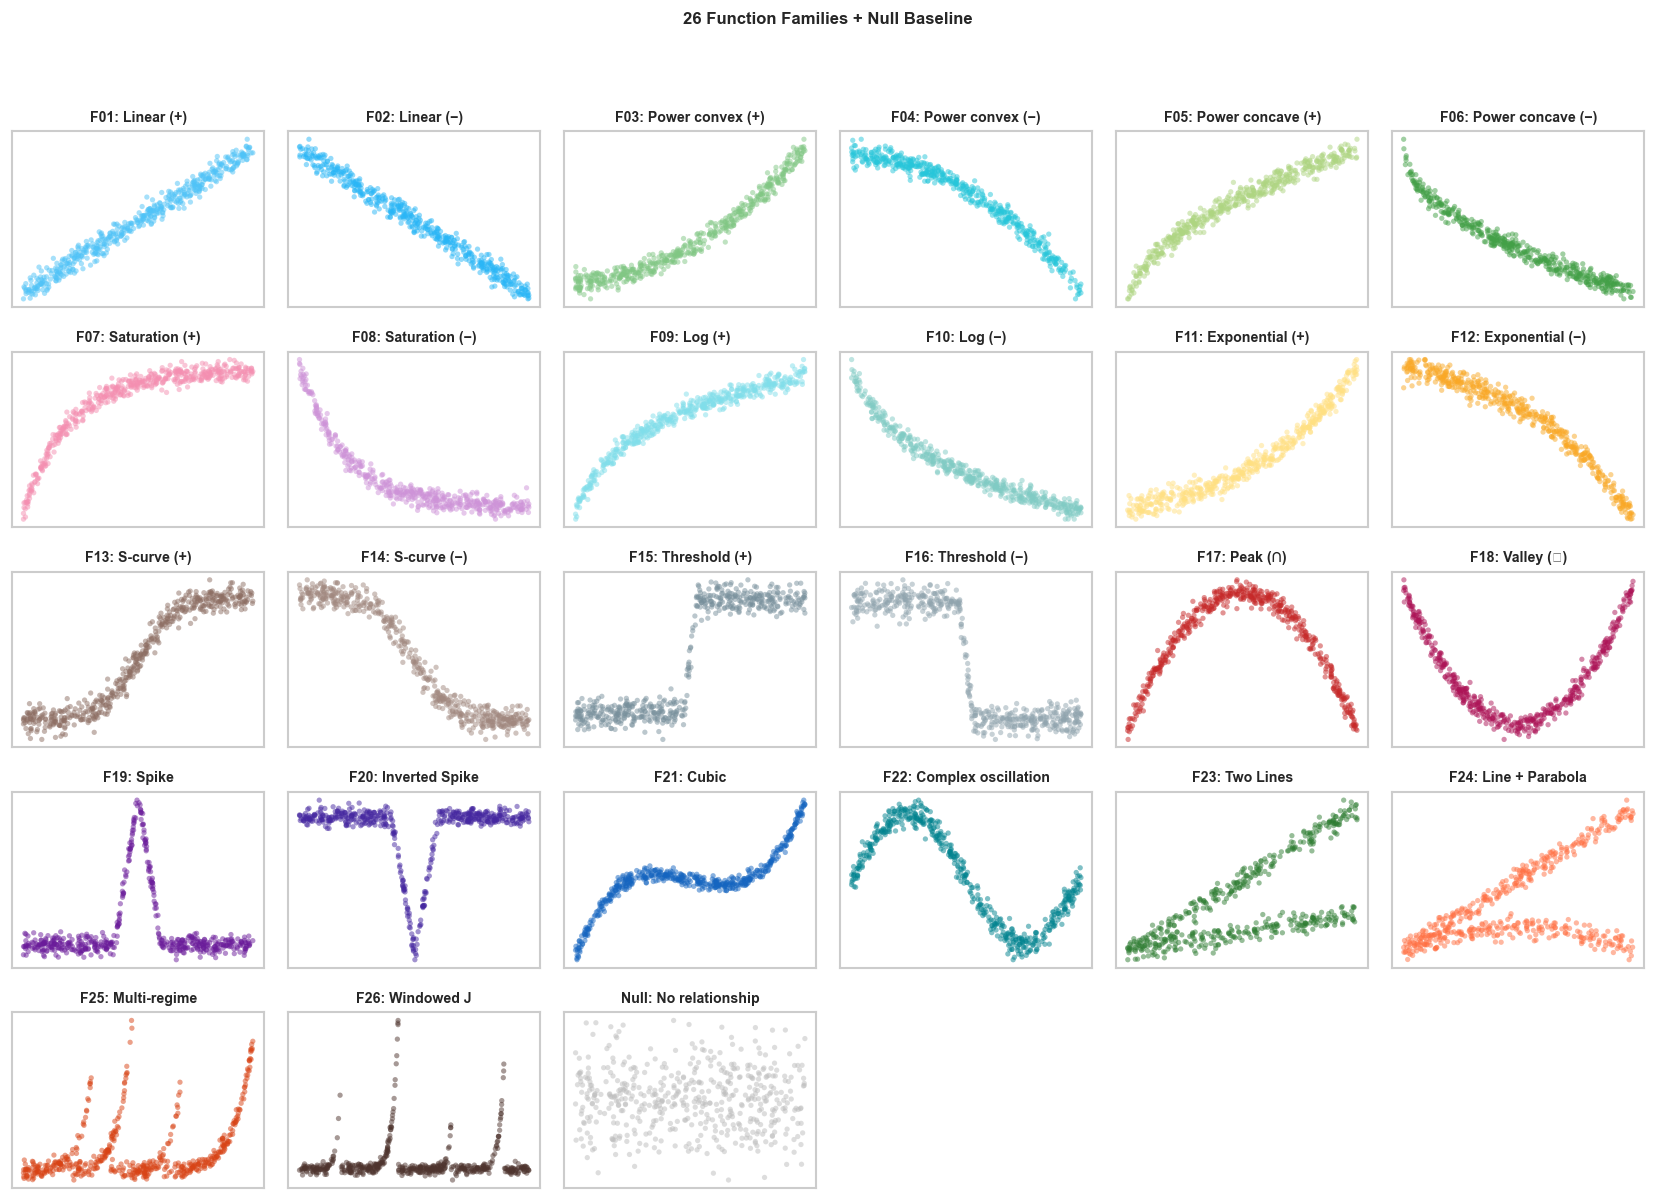

In [93]:
# ── 5×6 Overview: all 26 families + Null ──

pts = np.load(S1_DIR / 'scatter_points.npz')
x_all, y_all = pts['x'], pts['y']

overview_snr = 50.0
finite_snrs = [s for s in cases['snr'].unique()
               if str(s) != 'inf' and str(s) != 'nan']
finite_snrs = [float(s) for s in finite_snrs]
closest_overview_snr = min(finite_snrs, key=lambda s: abs(s - overview_snr))

all_family_ids = [f'F{i:02d}' for i in range(1, 27)] + ['Null']

SHORT_NAMES = {
    'F01': 'Linear (+)',       'F02': 'Linear (−)',
    'F03': 'Power convex (+)', 'F04': 'Power convex (−)',
    'F05': 'Power concave (+)','F06': 'Power concave (−)',
    'F07': 'Saturation (+)',   'F08': 'Saturation (−)',
    'F09': 'Log (+)',          'F10': 'Log (−)',
    'F11': 'Exponential (+)',  'F12': 'Exponential (−)',
    'F13': 'S-curve (+)',      'F14': 'S-curve (−)',
    'F15': 'Threshold (+)',    'F16': 'Threshold (−)',
    'F17': 'Peak (∩)',         'F18': 'Valley (∪)',
    'F19': 'Spike',            'F20': 'Inverted Spike',
    'F21': 'Cubic',            'F22': 'Complex oscillation',
    'F23': 'Two Lines',        'F24': 'Line + Parabola',
    'F25': 'Multi-regime',
    'F26': 'Windowed J',
    'Null': 'No relationship',
}

fig, axes = plt.subplots(5, 6, figsize=(14, 10))
fig.suptitle('26 Function Families + Null Baseline',
             fontsize=10, fontweight='bold', y=1.0)

for idx, (ax, fam_id) in enumerate(zip(axes.flat, all_family_ids)):
    label = SHORT_NAMES[fam_id]
    color = FAMILY_PALETTE.get(fam_id, '#5b9bd5')

    fam_cases = cases[(cases['family_id'] == fam_id) &
                      (cases['snr'] == closest_overview_snr) &
                      (cases['replicate'] == 0)]

    if len(fam_cases) > 0:
        case_idx = fam_cases.index[0]
        ax.scatter(x_all[case_idx], y_all[case_idx], s=10, alpha=0.5,
                   color=color, edgecolors='none')

    ax.set_title(f'{fam_id}: {label}', fontsize=8.5, fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])

for ax in axes.flat[len(all_family_ids):]:
    ax.set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

del x_all, y_all, pts

## Panel C — Metric Value vs SNR by Function Family

Each subplot shows one metric. X-axis = SNR (log scale, strong→weak left→right).  
Y-axis = metric value. Each family is a colored line (mean over 10 replicates).

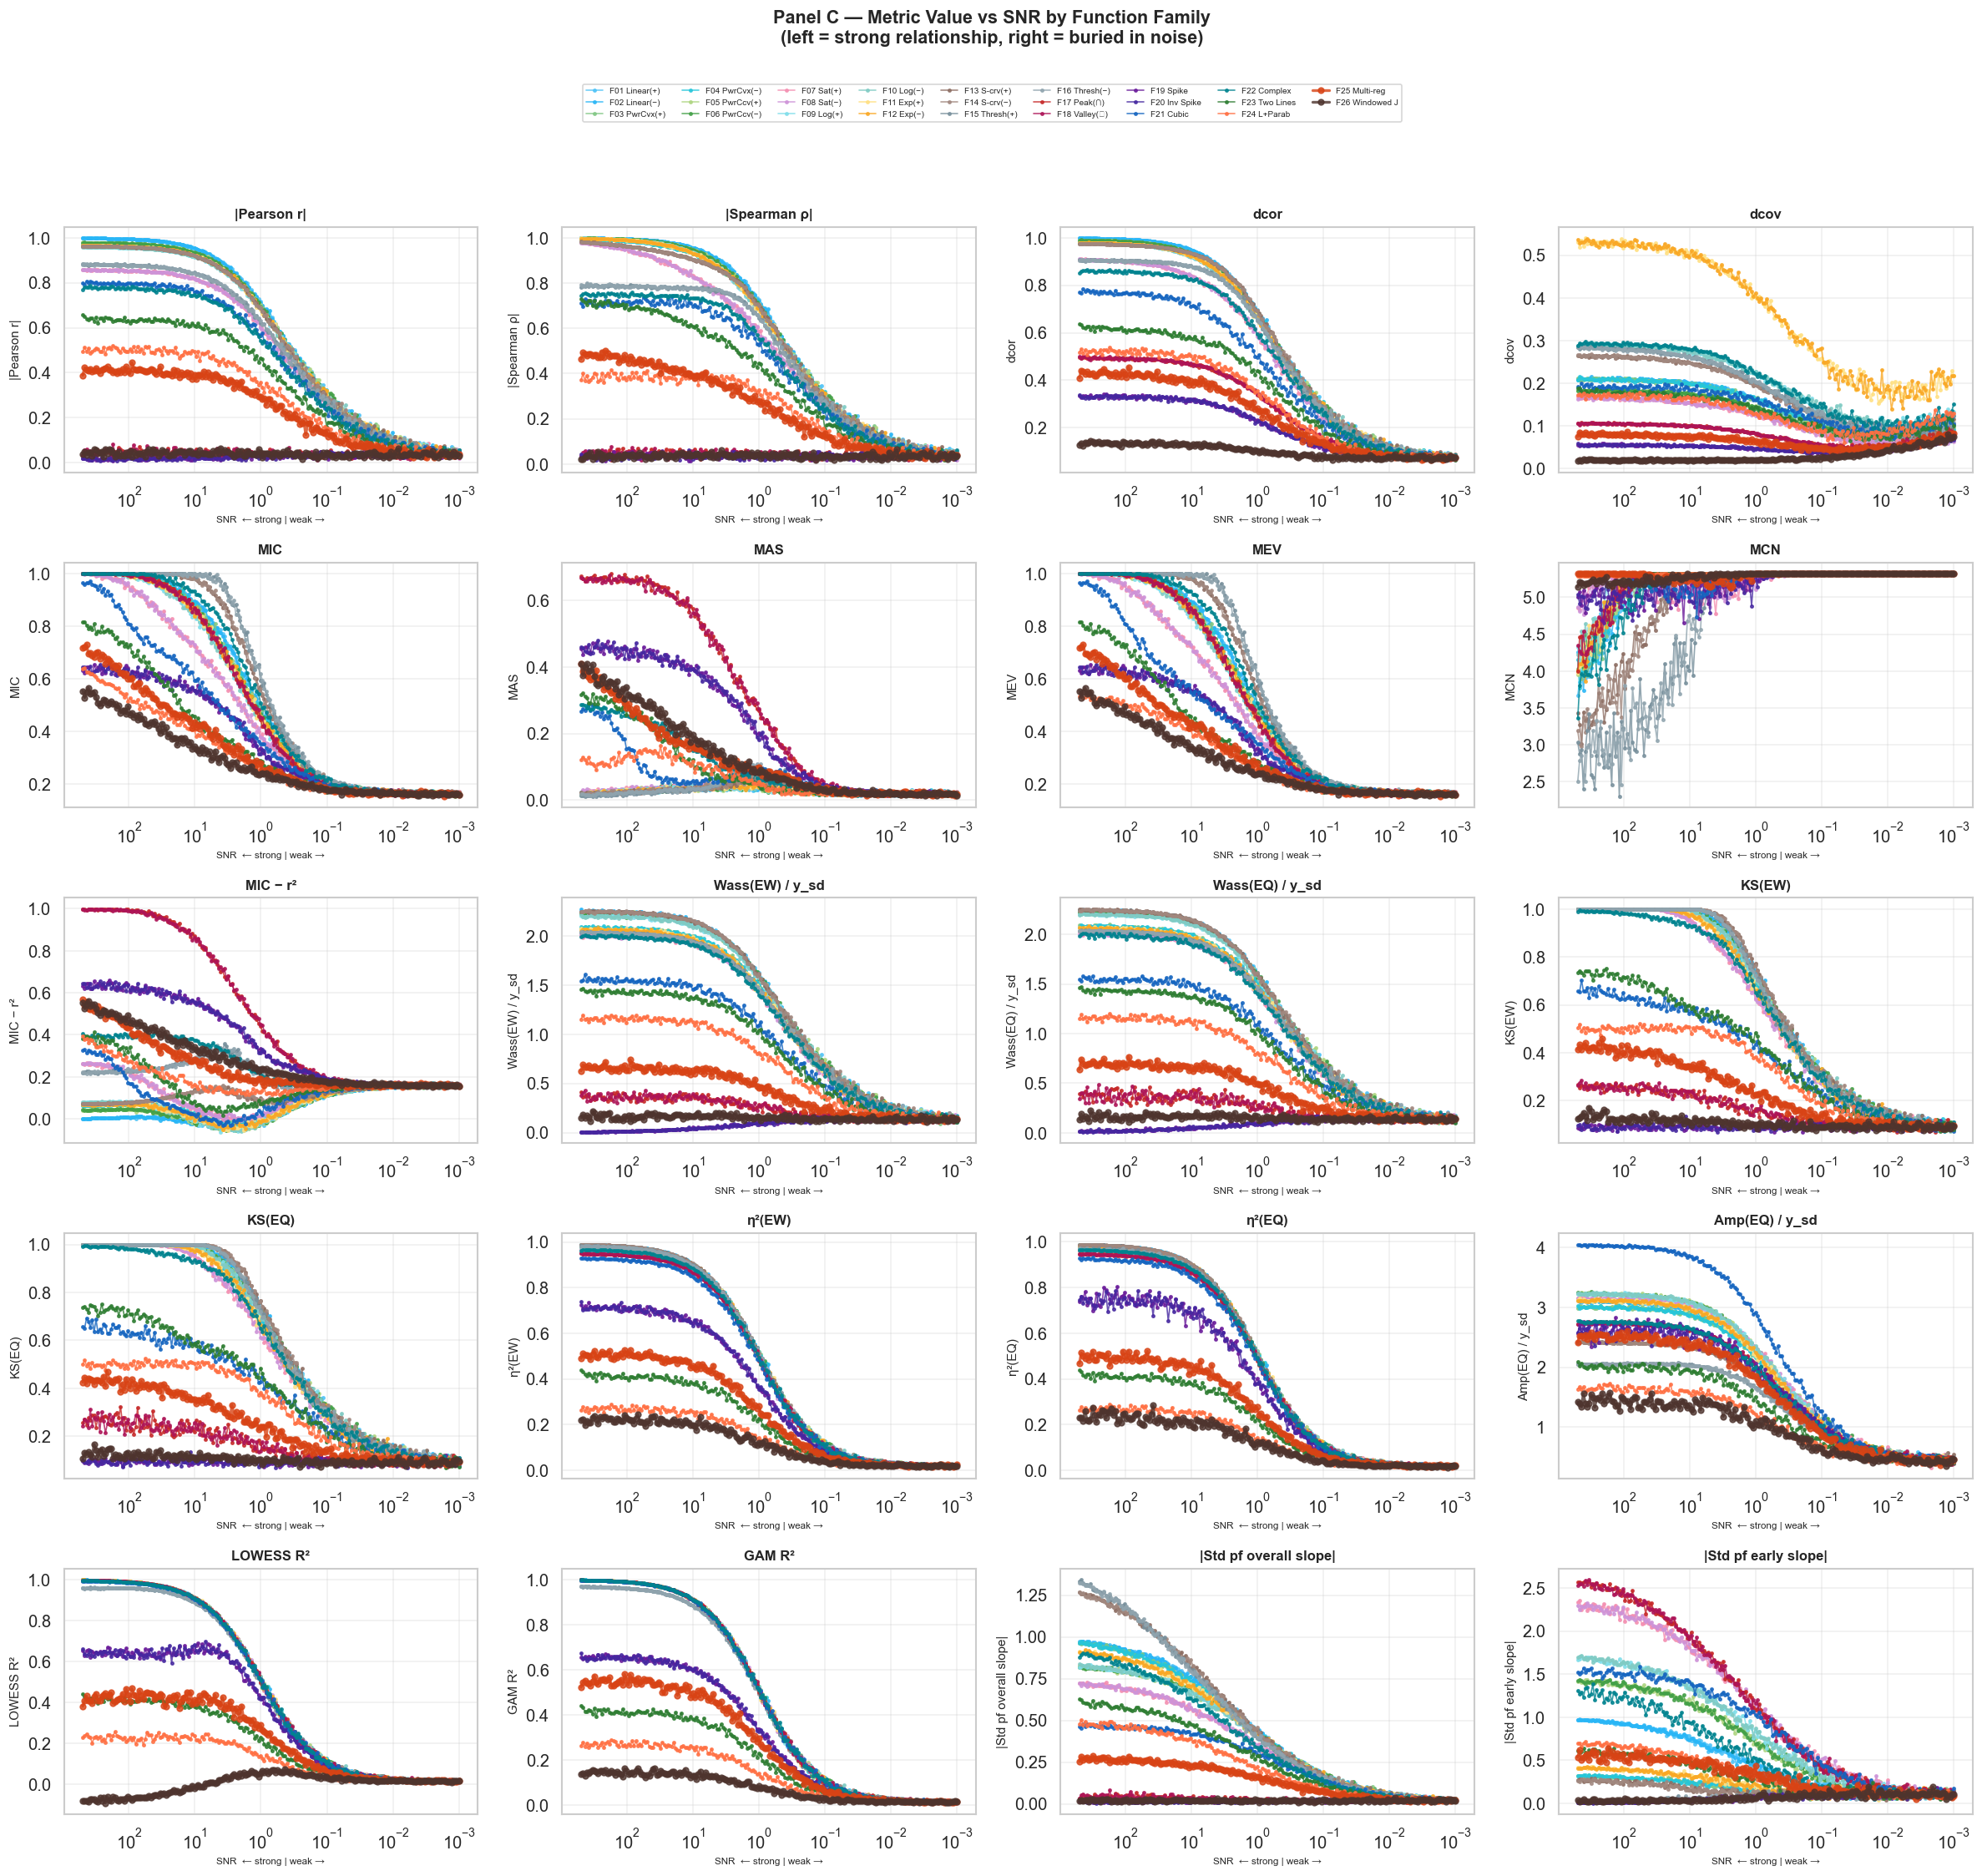

In [94]:
# ── Panel C: Metric value vs SNR by function family ──

SHORT = {
    'F01': 'Linear(+)',     'F02': 'Linear(−)',     'F03': 'PwrCvx(+)',
    'F04': 'PwrCvx(−)',    'F05': 'PwrCcv(+)',     'F06': 'PwrCcv(−)',
    'F07': 'Sat(+)',        'F08': 'Sat(−)',        'F09': 'Log(+)',
    'F10': 'Log(−)',        'F11': 'Exp(+)',        'F12': 'Exp(−)',
    'F13': 'S-crv(+)',      'F14': 'S-crv(−)',      'F15': 'Thresh(+)',
    'F16': 'Thresh(−)',     'F17': 'Peak(∩)',       'F18': 'Valley(∪)',
    'F19': 'Spike',         'F20': 'Inv Spike',     'F21': 'Cubic',
    'F22': 'Complex',       'F23': 'Two Lines',     'F24': 'L+Parab',
    'F25': 'Multi-reg',     'F26': 'Windowed J',
}

# All metrics from the Individual Power / Max-Z Driver ranking chart
PANEL_METRICS = [
    # ── Correlation ──
    ('pearson_r',            '|Pearson r|'),
    ('spearman_rho',         '|Spearman ρ|'),
    ('distance_correlation', 'dcor'),
    ('distance_covariance',  'dcov'),
    # ── MINE family ──
    ('MIC',                  'MIC'),
    ('MAS',                  'MAS'),
    ('MEV',                  'MEV'),
    ('MCN',                  'MCN'),
    ('MIC_minus_r2',         'MIC − r²'),
    # ── Distribution shift ──
    ('equal_width_distribution_wasserstein_distance_div_y_sd',  'Wass(EW) / y_sd'),
    ('equal_count_distribution_wasserstein_distance_div_y_sd',  'Wass(EQ) / y_sd'),
    ('equal_width_distribution_ks_distance',                    'KS(EW)'),
    ('equal_count_distribution_ks_distance',                    'KS(EQ)'),
    # ── Bin-based ──
    ('equal_width_bin_eta_squared',             'η²(EW)'),
    ('equal_count_bin_eta_squared',             'η²(EQ)'),
    ('equal_count_bin_amplitude_div_y_sd',      'Amp(EQ) / y_sd'),
    # ── Curve fitting ──
    ('lowess_r2',            'LOWESS R²'),
    ('gam_r2',              'GAM R²'),
    # ── Slope-based ──
    ('standardized_polyfit_overall_slope',  '|Std pf overall slope|'),
    ('standardized_polyfit_early_slope',    '|Std pf early slope|'),
]

ABS_METRICS = {'pearson_r', 'spearman_rho',
               'standardized_polyfit_overall_slope',
               'standardized_polyfit_early_slope'}

family_ids = sorted(signal['family_id'].unique())

ncols = 4
nrows = math.ceil(len(PANEL_METRICS) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
axes = axes.flatten()

for ax_i, (col, label) in enumerate(PANEL_METRICS):
    ax = axes[ax_i]
    for fid in family_ids:
        sub = signal[signal['family_id'] == fid].copy()
        vals = sub[col].copy()
        if col in ABS_METRICS:
            vals = vals.abs()
        sub = sub.assign(_val=vals)
        agg = sub.groupby('snr_val')['_val'].mean().reset_index()
        agg = agg.sort_values('snr_val', ascending=False)
        lw = 2.0 if fid in ('F25', 'F26') else 1.0
        ms = 4.0 if fid in ('F25', 'F26') else 2.0
        ax.plot(agg['snr_val'], agg['_val'], '-o',
                color=FAMILY_PALETTE[fid],
                markersize=ms, linewidth=lw, alpha=0.8,
                label=f'{fid} {SHORT.get(fid, "")}')
    ax.set_xscale('log')
    ax.invert_xaxis()
    ax.set_xlabel('SNR  ← strong | weak →', fontsize=7)
    ax.set_ylabel(label, fontsize=9)
    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.grid(True, alpha=0.3)

for ax_i in range(len(PANEL_METRICS), len(axes)):
    axes[ax_i].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=9,
           fontsize=6, frameon=True, bbox_to_anchor=(0.5, 1.03))
fig.suptitle('Panel C — Metric Value vs SNR by Function Family\n'
             '(left = strong relationship, right = buried in noise)',
             fontsize=13, fontweight='bold', y=1.07)
plt.tight_layout()
plt.show()

## Panel D — Key Metrics: Fresh vs Muted Families

Top row: F01–F12 (simple monotonic/symmetric shapes).  
Bottom row: F13–F26 (complex, multi-branch, threshold shapes).

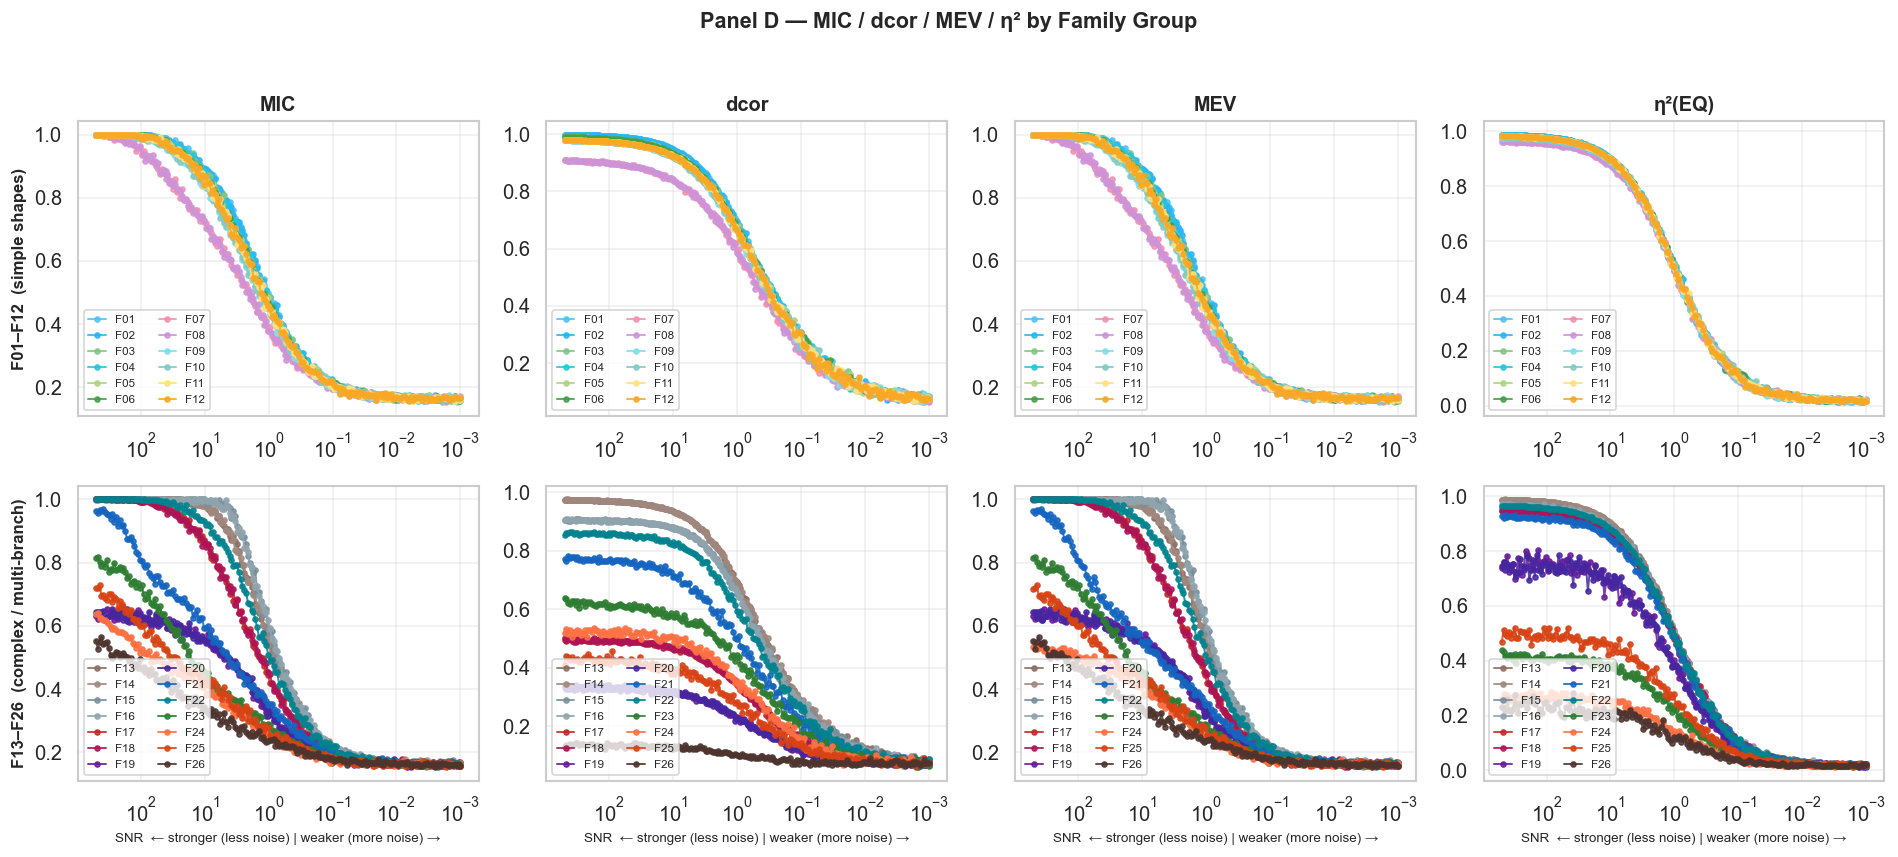

In [99]:
# ── Panel D: Key metrics split by family group ──

SPLIT_METRICS = [
    ('MIC',                  'MIC'),
    ('distance_correlation', 'dcor'),
    ('MEV',                  'MEV'),
    ('equal_count_bin_eta_squared', 'η²(EQ)'),
]

group1 = [f'F{i:02d}' for i in range(1, 13)]   # F01–F12
group2 = [f'F{i:02d}' for i in range(13, 27)]   # F13–F26
groups = [
    (group1, 'F01–F12  (simple shapes)'),
    (group2, 'F13–F26  (complex / multi-branch)'),
]

fig, axes = plt.subplots(2, len(SPLIT_METRICS),
                         figsize=(4 * len(SPLIT_METRICS), 3.5 * 2))

for ri, (fids, grp_label) in enumerate(groups):
    for ci, (col, label) in enumerate(SPLIT_METRICS):
        ax = axes[ri, ci]
        for fid in fids:
            sub = signal[signal['family_id'] == fid]
            agg = sub.groupby('snr_val')[col].mean().reset_index()
            agg = agg.sort_values('snr_val', ascending=False)
            ax.plot(agg['snr_val'], agg[col], '-o',
                    color=FAMILY_PALETTE[fid],
                    markersize=3, linewidth=1.2, alpha=0.85,
                    label=fid)
        ax.set_xscale('log')
        ax.invert_xaxis()
        ax.grid(True, alpha=0.3)
        if ri == 0:
            ax.set_title(label, fontweight='bold', fontsize=12)
        if ri == 1:
            ax.set_xlabel('SNR  ← stronger (less noise) | weaker (more noise) →',
                          fontsize=8)
        if ci == 0:
            ax.set_ylabel(grp_label, fontsize=10, fontweight='bold')
        ax.legend(fontsize=7, ncol=2, loc='lower left',
                  framealpha=0.8, handlelength=1.5)

fig.suptitle('Panel D — MIC / dcor / MEV / η² by Family Group',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

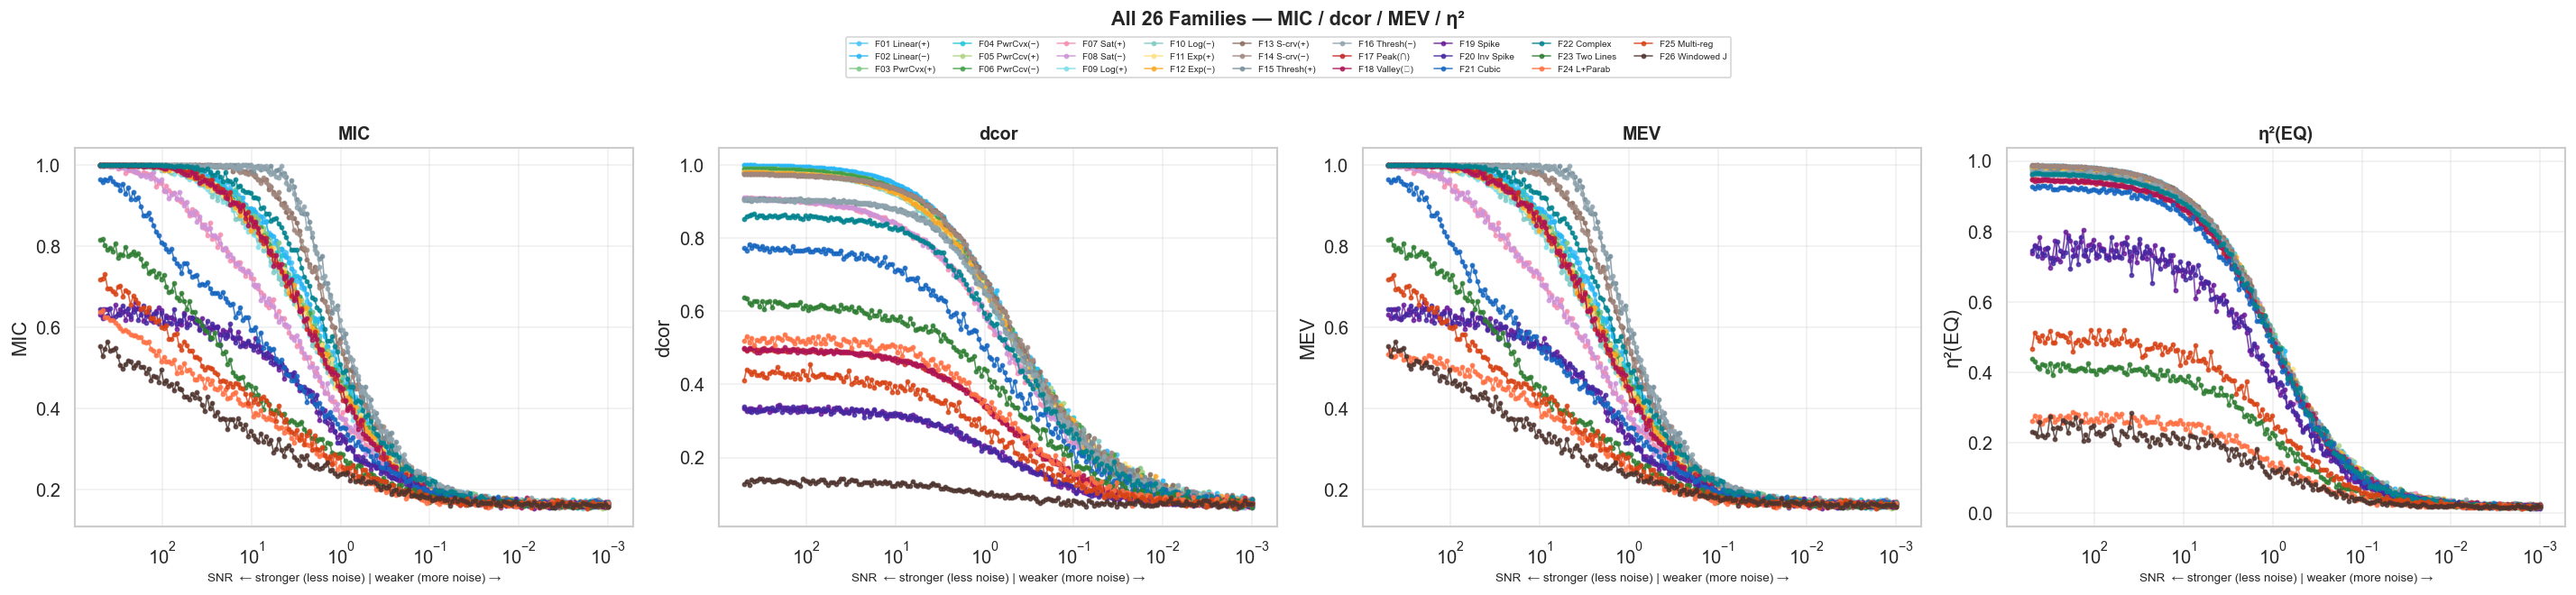


Families with mean metric ≥ 0.8 for ALL SNR ≥ 10

MIC (17 families):
  ✓ F01 (Linear(+))
  ✓ F02 (Linear(−))
  ✓ F03 (PwrCvx(+))
  ✓ F04 (PwrCvx(−))
  ✓ F05 (PwrCcv(+))
  ✓ F06 (PwrCcv(−))
  ✓ F09 (Log(+))
  ✓ F10 (Log(−))
  ✓ F11 (Exp(+))
  ✓ F12 (Exp(−))
  ✓ F13 (S-crv(+))
  ✓ F14 (S-crv(−))
  ✓ F15 (Thresh(+))
  ✓ F16 (Thresh(−))
  ✓ F17 (Peak(∩))
  ✓ F18 (Valley(∪))
  ✓ F22 (Complex)

dcor (17 families):
  ✓ F01 (Linear(+))
  ✓ F02 (Linear(−))
  ✓ F03 (PwrCvx(+))
  ✓ F04 (PwrCvx(−))
  ✓ F05 (PwrCcv(+))
  ✓ F06 (PwrCcv(−))
  ✓ F07 (Sat(+))
  ✓ F08 (Sat(−))
  ✓ F09 (Log(+))
  ✓ F10 (Log(−))
  ✓ F11 (Exp(+))
  ✓ F12 (Exp(−))
  ✓ F13 (S-crv(+))
  ✓ F14 (S-crv(−))
  ✓ F15 (Thresh(+))
  ✓ F16 (Thresh(−))
  ✓ F22 (Complex)

MEV (17 families):
  ✓ F01 (Linear(+))
  ✓ F02 (Linear(−))
  ✓ F03 (PwrCvx(+))
  ✓ F04 (PwrCvx(−))
  ✓ F05 (PwrCcv(+))
  ✓ F06 (PwrCcv(−))
  ✓ F09 (Log(+))
  ✓ F10 (Log(−))
  ✓ F11 (Exp(+))
  ✓ F12 (Exp(−))
  ✓ F13 (S-crv(+))
  ✓ F14 (S-crv(−))
  ✓ F15 (Thresh(+))
  ✓

In [115]:
# ── Panel D (combined): all 26 families in one plot per metric ──

SHORT = {
    'F01': 'Linear(+)',     'F02': 'Linear(−)',     'F03': 'PwrCvx(+)',
    'F04': 'PwrCvx(−)',    'F05': 'PwrCcv(+)',     'F06': 'PwrCcv(−)',
    'F07': 'Sat(+)',        'F08': 'Sat(−)',        'F09': 'Log(+)',
    'F10': 'Log(−)',        'F11': 'Exp(+)',        'F12': 'Exp(−)',
    'F13': 'S-crv(+)',      'F14': 'S-crv(−)',      'F15': 'Thresh(+)',
    'F16': 'Thresh(−)',     'F17': 'Peak(∩)',       'F18': 'Valley(∪)',
    'F19': 'Spike',         'F20': 'Inv Spike',     'F21': 'Cubic',
    'F22': 'Complex',       'F23': 'Two Lines',     'F24': 'L+Parab',
    'F25': 'Multi-reg',     'F26': 'Windowed J',
}

COMB_METRICS = [
    ('MIC', 'MIC'),
    ('distance_correlation', 'dcor'),
    ('MEV', 'MEV'),
    ('equal_count_bin_eta_squared', 'η²(EQ)'),
]

all_fids = [f'F{i:02d}' for i in range(1, 27)]

fig, axes = plt.subplots(1, len(COMB_METRICS), figsize=(6 * len(COMB_METRICS), 5))

for ax, (col, label) in zip(axes, COMB_METRICS):
    for fid in all_fids:
        sub = signal[signal['family_id'] == fid]
        agg = sub.groupby('snr_val')[col].mean().reset_index()
        agg = agg.sort_values('snr_val', ascending=False)
        ax.plot(agg['snr_val'], agg[col], '-o',
                color=FAMILY_PALETTE[fid],
                markersize=2.5, linewidth=1.0, alpha=0.8,
                label=f'{fid} {SHORT.get(fid, "")}')
    ax.set_xscale('log')
    ax.invert_xaxis()
    ax.grid(True, alpha=0.3)
    ax.set_title(label, fontweight='bold', fontsize=12)
    ax.set_xlabel('SNR  ← stronger (less noise) | weaker (more noise) →', fontsize=8)
    ax.set_ylabel(label)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=9,
           fontsize=6, frameon=True, bbox_to_anchor=(0.5, 1.06))
fig.suptitle('All 26 Families — MIC / dcor / MEV / η²',
             fontsize=13, fontweight='bold', y=1.10)
plt.tight_layout()
plt.show()

# ── Print families with metric ≥ 0.8 across SNR ∈ [10, ∞) ──
print('\n' + '='*70)
print('Families with mean metric ≥ 0.8 for ALL SNR ≥ 10')
print('='*70)
for col, label in COMB_METRICS:
    qualified = []
    for fid in all_fids:
        sub = signal[signal['family_id'] == fid]
        agg = sub.groupby('snr_val')[col].mean().reset_index()
        high_snr = agg[agg['snr_val'] >= 10]
        if len(high_snr) > 0 and high_snr[col].min() >= 0.8:
            qualified.append(f'{fid} ({SHORT[fid]})')
    print(f'\n{label} ({len(qualified)} families):')
    for q in qualified:
        print(f'  ✓ {q}')

In [ ]:
# ── Panel D (combined, filtered): families with most points ≥ 0.8 ──

THRESH = 0.8
FRAC_ABOVE = 0.5  # at least 50% of SNR levels (SNR ≥ 1) have metric ≥ 0.8

fig, axes = plt.subplots(1, len(COMB_METRICS), figsize=(6 * len(COMB_METRICS), 5))

legend_fids = set()

for ax, (col, label) in zip(axes, COMB_METRICS):
    for fid in all_fids:
        sub = signal[signal['family_id'] == fid]
        agg = sub.groupby('snr_val')[col].mean().reset_index()
        agg = agg.sort_values('snr_val', ascending=False)
        high = agg[agg['snr_val'] >= 1]
        if len(high) == 0:
            continue
        frac = (high[col] >= THRESH).mean()
        if frac < FRAC_ABOVE:
            continue
        legend_fids.add(fid)
        ax.plot(agg['snr_val'], agg[col], '-o',
                color=FAMILY_PALETTE[fid],
                markersize=2.5, linewidth=1.0, alpha=0.85,
                label=f'{fid} {SHORT.get(fid, "")}')
    ax.axhline(THRESH, color='red', linestyle='--', linewidth=1.0, alpha=0.6)
    ax.set_xscale('log')
    ax.invert_xaxis()
    ax.grid(True, alpha=0.3)
    ax.set_title(label, fontweight='bold', fontsize=12)
    ax.set_xlabel('SNR  ← stronger | weaker →', fontsize=8)
    ax.set_ylabel(label)

legend_order = [f for f in all_fids if f in legend_fids]
from matplotlib.lines import Line2D
handles = [Line2D([0], [0], color=FAMILY_PALETTE[f], marker='o',
                  markersize=4, linewidth=1.2,
                  label=f'{f} {SHORT.get(f, "")}') for f in legend_order]
fig.legend(handles=handles, loc='upper center', ncol=9,
           fontsize=6, frameon=True, bbox_to_anchor=(0.5, 1.06))
fig.suptitle(f'Families with ≥ {int(FRAC_ABOVE*100)}% Points Above {THRESH} (SNR ≥ 1)',
             fontsize=13, fontweight='bold', y=1.10)
plt.tight_layout()
plt.show()

# Print summary
print(f'\nFilter: family shown if ≥ {int(FRAC_ABOVE*100)}% of SNR levels (∞ to 1) have mean metric ≥ {THRESH}')
for col, label in COMB_METRICS:
    qualified = []
    for fid in all_fids:
        sub = signal[signal['family_id'] == fid]
        agg = sub.groupby('snr_val')[col].mean().reset_index()
        high = agg[agg['snr_val'] >= 1]
        if len(high) == 0:
            continue
        frac = (high[col] >= THRESH).mean()
        if frac >= FRAC_ABOVE:
            qualified.append(f'{fid} ({SHORT[fid]}) — {frac:.0%}')
    print(f'\n{label} ({len(qualified)} families):')
    for q in qualified:
        print(f'  ✓ {q}')


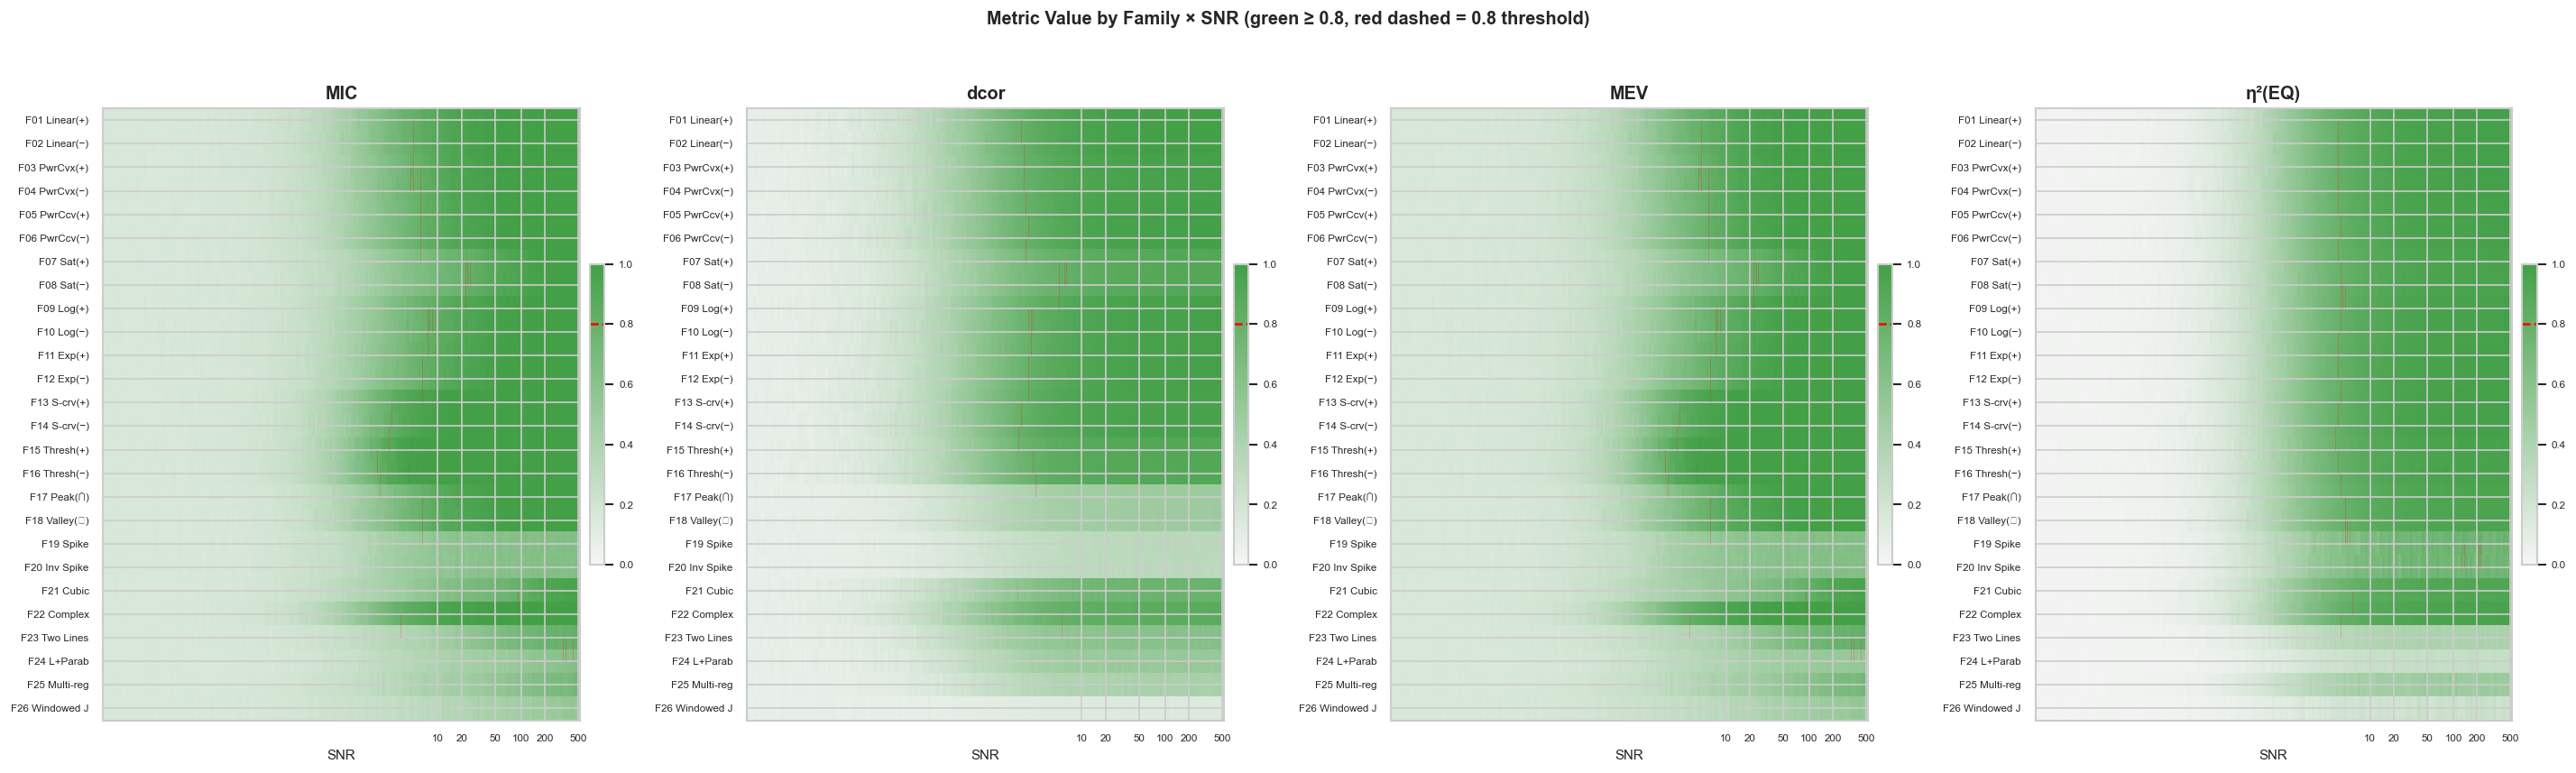

In [116]:
# ── Panel D (heatmap): families × SNR — metric ≥ 0.8 indicator ──

HEAT_METRICS = [
    ('MIC', 'MIC'),
    ('distance_correlation', 'dcor'),
    ('MEV', 'MEV'),
    ('equal_count_bin_eta_squared', 'η²(EQ)'),
]

all_fids = [f'F{i:02d}' for i in range(1, 27)]

SHORT_H = {
    'F01': 'Linear(+)',     'F02': 'Linear(−)',     'F03': 'PwrCvx(+)',
    'F04': 'PwrCvx(−)',    'F05': 'PwrCcv(+)',     'F06': 'PwrCcv(−)',
    'F07': 'Sat(+)',        'F08': 'Sat(−)',        'F09': 'Log(+)',
    'F10': 'Log(−)',        'F11': 'Exp(+)',        'F12': 'Exp(−)',
    'F13': 'S-crv(+)',      'F14': 'S-crv(−)',      'F15': 'Thresh(+)',
    'F16': 'Thresh(−)',     'F17': 'Peak(∩)',       'F18': 'Valley(∪)',
    'F19': 'Spike',         'F20': 'Inv Spike',     'F21': 'Cubic',
    'F22': 'Complex',       'F23': 'Two Lines',     'F24': 'L+Parab',
    'F25': 'Multi-reg',     'F26': 'Windowed J',
}

# Aggregate: mean metric per (family, snr), keep only finite SNR
sig = signal[np.isfinite(signal['snr_val'])].copy()
snr_levels = sorted(sig['snr_val'].unique())

from matplotlib.colors import LinearSegmentedColormap
cmap_bin = LinearSegmentedColormap.from_list('bin08', ['#F5F5F5', '#43A047'], N=256)

fig, axes = plt.subplots(1, len(HEAT_METRICS), figsize=(6 * len(HEAT_METRICS), 7))

for ax, (col, label) in zip(axes, HEAT_METRICS):
    mat = np.full((len(all_fids), len(snr_levels)), np.nan)
    for i, fid in enumerate(all_fids):
        sub = sig[sig['family_id'] == fid]
        agg = sub.groupby('snr_val')[col].mean()
        for j, s in enumerate(snr_levels):
            if s in agg.index:
                mat[i, j] = agg[s]

    im = ax.imshow(mat, aspect='auto', vmin=0, vmax=1, cmap=cmap_bin,
                   interpolation='nearest')

    # 0.8 contour: for each family, find the SNR where it crosses 0.8
    for i in range(len(all_fids)):
        row = mat[i]
        for j in range(len(snr_levels) - 1):
            if (row[j] >= 0.8 and row[j+1] < 0.8) or (row[j] < 0.8 and row[j+1] >= 0.8):
                ax.axvline(j + 0.5, ymin=(len(all_fids) - i - 1.5) / len(all_fids),
                           ymax=(len(all_fids) - i - 0.5) / len(all_fids),
                           color='red', linewidth=0.3, alpha=0.4)

    # SNR x-axis: show sparse ticks
    tick_snrs = [10, 20, 50, 100, 200, 500]
    tick_pos = []
    tick_lab = []
    for ts in tick_snrs:
        closest = min(range(len(snr_levels)), key=lambda j: abs(snr_levels[j] - ts))
        tick_pos.append(closest)
        tick_lab.append(str(ts))
    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_lab, fontsize=7)
    ax.set_xlabel('SNR', fontsize=9)

    ax.set_yticks(range(len(all_fids)))
    ax.set_yticklabels([f'{f} {SHORT_H[f]}' for f in all_fids], fontsize=7)
    ax.set_title(label, fontweight='bold', fontsize=12)

    # Draw horizontal line at 0.8 as reference in colorbar
    cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.ax.axhline(0.8, color='red', linewidth=1.5, linestyle='--')
    cbar.ax.tick_params(labelsize=7)

fig.suptitle('Metric Value by Family × SNR (green ≥ 0.8, red dashed = 0.8 threshold)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Panel E — MCN by Family Group

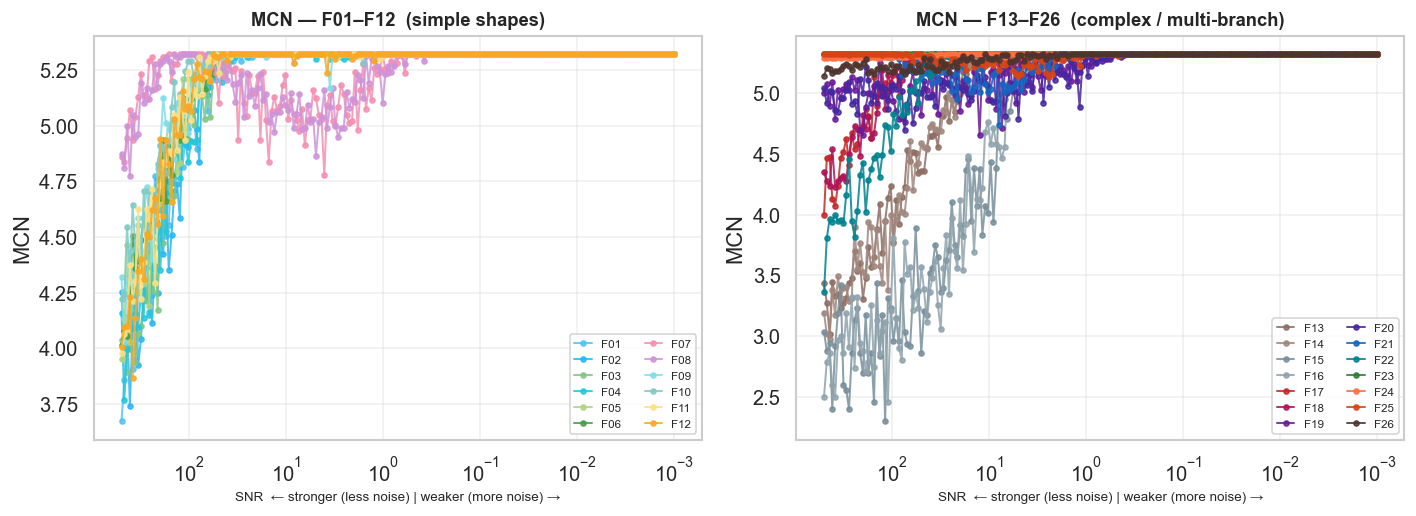

In [96]:
# ── Panel E: MCN split by family group ──

group1 = [f'F{i:02d}' for i in range(1, 13)]
group2 = [f'F{i:02d}' for i in range(13, 27)]
groups = [
    (group1, 'F01–F12  (simple shapes)'),
    (group2, 'F13–F26  (complex / multi-branch)'),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, (fids, grp_label) in zip(axes, groups):
    for fid in fids:
        sub = signal[signal['family_id'] == fid]
        agg = sub.groupby('snr_val')['MCN'].mean().reset_index()
        agg = agg.sort_values('snr_val', ascending=False)
        ax.plot(agg['snr_val'], agg['MCN'], '-o',
                color=FAMILY_PALETTE[fid],
                markersize=3, linewidth=1.2, alpha=0.85,
                label=fid)
    ax.set_xscale('log')
    ax.invert_xaxis()
    ax.grid(True, alpha=0.3)
    ax.set_title(f'MCN — {grp_label}', fontweight='bold', fontsize=11)
    ax.set_xlabel('SNR  ← stronger (less noise) | weaker (more noise) →', fontsize=8)
    ax.set_ylabel('MCN')
    ax.legend(fontsize=7, ncol=2, loc='best', framealpha=0.8, handlelength=1.5)

plt.tight_layout()
plt.show()